# Read Motor Data With Zero Torque

This notebook sends zero torque for a fixed duration while you rotate the motor by hand. After recording, it plots motor history: continuous unwrapped position, raw wrapped position, velocity, and current.

Keep the motor mechanically safe: zero torque means the motor is not actively held.

In [ ]:
from pathlib import Path
from datetime import datetime
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SCRIPT_DIR = Path.cwd() if Path.cwd().name == "scripts" else Path.cwd() / "scripts"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from motor_position import POS_PERIOD_RAD, rotation_check, unwrap_motor_position

import encosid

/home/slava/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Configuration

Set the motor interface/id and duration here. When ready to record, set `RUN_RECORDING = True`, run the recording cell, and rotate the motor by hand for `DURATION_S` seconds.

In [ ]:
MOTOR_IF = "can0"
MOTOR_ID = 3

DT_MS = 1
DURATION_S = 5

RUN_RECORDING = True
SAVE_CSV = False

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "data" / "manual"

In [ ]:
def record_zero_torque(
    duration_s: float = DURATION_S,
    dt_ms: float = DT_MS,
    motor_if: str = MOTOR_IF,
    motor_id: int = MOTOR_ID,
) -> pd.DataFrame:
    sample_count = int(round(duration_s * 1000 / dt_ms))
    time_s = np.arange(sample_count, dtype=float) * dt_ms * 1e-3
    qact = np.zeros(sample_count, dtype=float)

    gen = encosid.SignalGenerator(motor_if, motor_id)
    gen.set_mode(gen.mode.torque, 0)

    print(f"Recording {duration_s:.1f} s with zero torque ({sample_count} samples)...")
    qpos_raw, qvel, qcur = map(np.asarray, gen.play_signal(qact.tolist(), dt_ms))
    qpos = unwrap_motor_position(qpos_raw)
    print("Recording finished")

    return pd.DataFrame(
        {
            "time_s": time_s,
            "qpos": qpos,
            "qpos_raw": qpos_raw,
            "qvel": qvel,
            "qcur": qcur,
            "qact": qact,
        }
    )


def save_recording(df: pd.DataFrame, output_dir: Path = OUTPUT_DIR) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_path = output_dir / f"zero_torque_manual_{timestamp}.csv"
    df.to_csv(output_path, index=False)
    return output_path

## Record

Set `RUN_RECORDING = True`, start this cell, then rotate the motor by hand until the 20 second recording finishes.

In [ ]:
if RUN_RECORDING:
    motor_history = record_zero_torque()
    if SAVE_CSV:
        saved_path = save_recording(motor_history)
        print(f"Saved recording to {saved_path}")
else:
    print("RUN_RECORDING is False. Set it to True when you are ready to record.")
    motor_history = pd.DataFrame()

Recording 5.0 s with zero torque (5000 samples)...
Recording finished


In [ ]:
if motor_history.empty:
    print("No motor history recorded yet.")
else:
    display(motor_history.head())
    display(motor_history.tail())

,time_s,qpos,qpos_raw,qvel,qcur,qact
0,0.000,-0.037843,-0.037843,0.000000,0.000000,0.0
1,0.001,-0.037843,-0.037843,0.009768,-0.146521,0.0
2,0.002,-0.037843,-0.037843,0.000000,0.000000,0.0
3,0.003,-0.037843,-0.037843,0.000000,0.000000,0.0
4,0.004,-0.037843,-0.037843,0.000000,-0.043957,0.0


,time_s,qpos,qpos_raw,qvel,qcur,qact
4995,4.995,-0.037843,-0.037843,0.019537,-0.029305,0.0
4996,4.996,-0.037843,-0.037843,-0.019537,0.000000,0.0
4997,4.997,-0.037843,-0.037843,-0.019537,0.043957,0.0
4998,4.998,-0.037843,-0.037843,0.019537,0.029305,0.0
4999,4.999,-0.037843,-0.037843,0.009768,0.087912,0.0


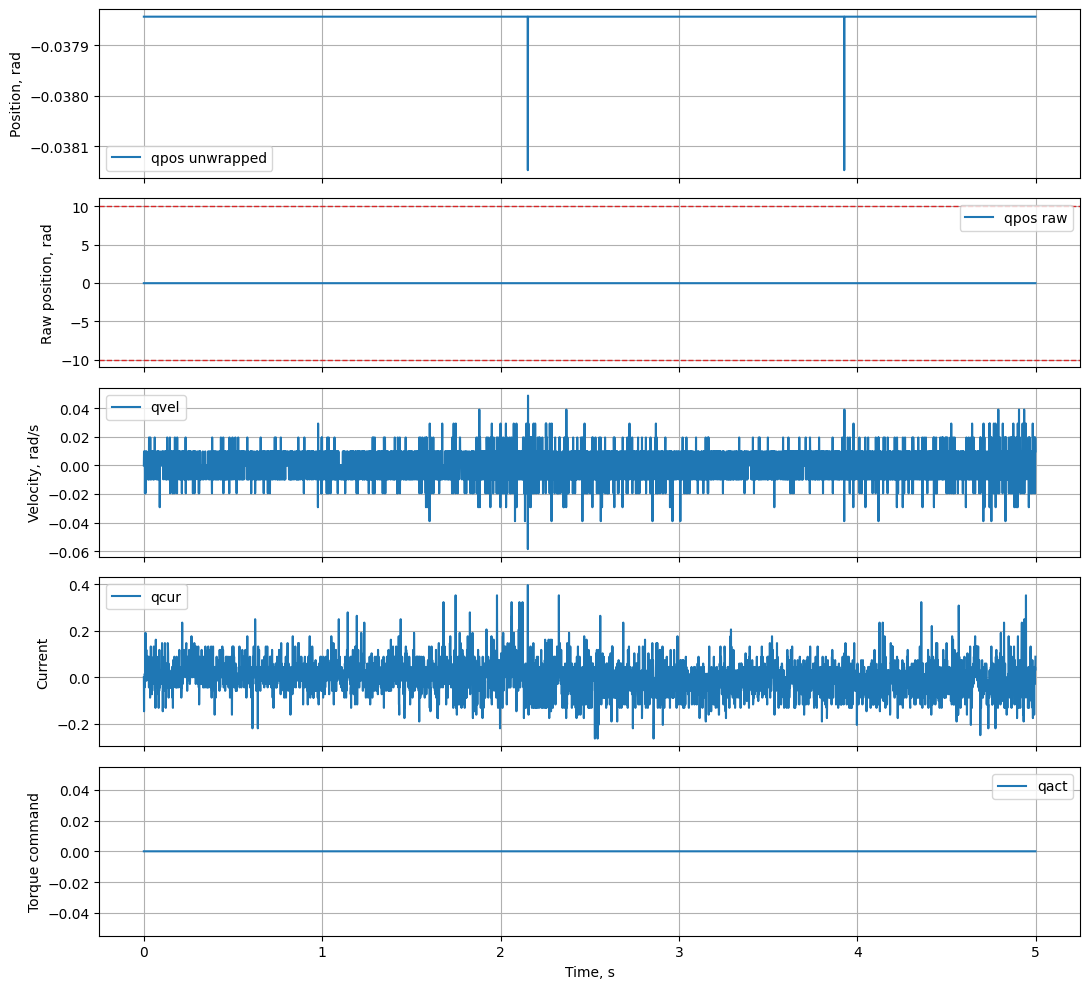

In [ ]:
if not motor_history.empty:
    fig, ax = plt.subplots(5, 1, figsize=(11, 10), sharex=True)

    ax[0].plot(motor_history["time_s"], motor_history["qpos"], label="qpos unwrapped")
    ax[0].set_ylabel("Position, rad")

    ax[1].plot(motor_history["time_s"], motor_history["qpos_raw"], label="qpos raw")
    ax[1].set_ylabel("Raw position, rad")
    ax[1].axhline(POS_PERIOD_RAD / 2, color="tab:red", linestyle="--", linewidth=1)
    ax[1].axhline(-POS_PERIOD_RAD / 2, color="tab:red", linestyle="--", linewidth=1)

    ax[2].plot(motor_history["time_s"], motor_history["qvel"], label="qvel")
    ax[2].set_ylabel("Velocity, rad/s")

    ax[3].plot(motor_history["time_s"], motor_history["qcur"], label="qcur")
    ax[3].set_ylabel("Current")

    ax[4].plot(motor_history["time_s"], motor_history["qact"], label="qact")
    ax[4].set_ylabel("Torque command")
    ax[4].set_xlabel("Time, s")

    for axis in ax:
        axis.grid()
        axis.legend()

    plt.tight_layout()
    plt.show()

## Rotation Scale Check

After recording, set how many full rotations you made by hand. Use `DIRECTION = 1` if the unwrapped position increased, or `-1` if it decreased.

In [ ]:
N_ROTATIONS = 1
DIRECTION = 1

if motor_history.empty:
    print("No motor history recorded yet.")
else:
    check = rotation_check(
        motor_history["qpos_raw"].to_numpy(),
        n_rotations=N_ROTATIONS,
        direction=DIRECTION,
    )
    print(f"Position feedback period used for unwrap: {POS_PERIOD_RAD:.6f} rad")
    print(f"Measured delta: {check['measured_delta_rad']:.6f} rad")
    print(f"Expected delta: {check['expected_delta_rad']:.6f} rad")
    print(f"Error:          {check['error_rad']:.6f} rad")
    print(f"Error/turn:     {check['error_per_turn_rad']:.6f} rad")
    print(f"Scale:          {check['scale']:.6f}")

Position feedback period used for unwrap: 20.000000 rad
Measured delta: 0.000000 rad
Expected delta: 6.283185 rad
Error:          -6.283185 rad
Error/turn:     -6.283185 rad
Scale:          0.000000


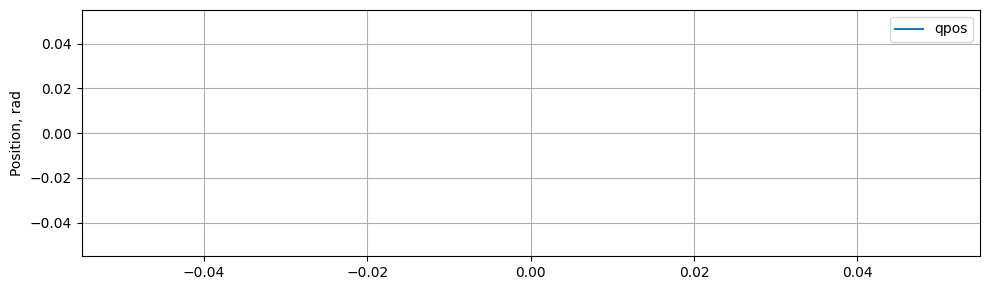

nan nan
nan
nan


In [ ]:
START, END = 7000,13000
if not motor_history.empty:
    fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

    ax.plot(motor_history["time_s"][START:END], motor_history["qpos"][START:END], label="qpos")
    ax.set_ylabel("Position, rad")

    # for axis in ax:
    ax.grid()
    ax.legend()

    plt.tight_layout()
    plt.show()
    print(motor_history["qpos"][START:END].max(),motor_history["qpos"][START:END].min())
    print(motor_history["qpos"][START:END].max()-motor_history["qpos"][START:END].min())
    print((motor_history["qpos"][START:END].max()-motor_history["qpos"][START:END].min())/np.pi)